In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
import matplotlib.ticker as ticker
import plotly.express as px

In [15]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x) 
sns.set_palette("colorblind")
sns.set_style("whitegrid")
sns.set_context("talk")
warnings.filterwarnings('ignore') 
plt.rcParams['axes.formatter.limits'] = (-20, 20)

In [16]:
df_raw = pd.read_csv('ai4i2020.csv')
df = df_raw.copy()


<Axes: >

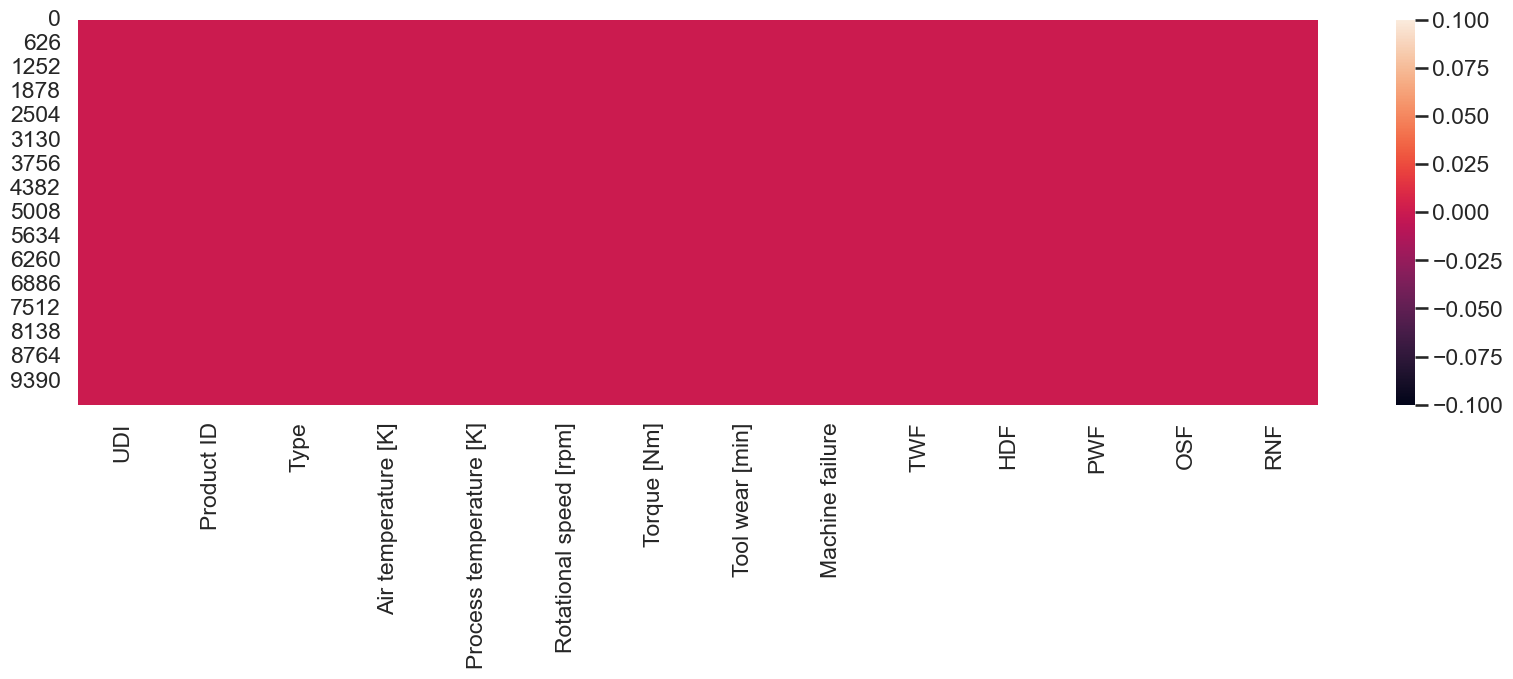

In [17]:
plt.figure(figsize=(20, 5))
sns.heatmap(df.isnull())

In [18]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,300.00,310.01,1538.78,39.99,107.95,0.03,0.00,0.01,0.01,0.01,0.00
std,2886.90,2.00,1.48,179.28,9.97,63.65,0.18,0.07,0.11,0.10,0.10,0.04
min,1.00,295.30,305.70,1168.00,3.80,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,2500.75,298.30,308.80,1423.00,33.20,53.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,5000.50,300.10,310.10,1503.00,40.10,108.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,7500.25,301.50,311.10,1612.00,46.80,162.00,0.00,0.00,0.00,0.00,0.00,0.00
max,10000.00,304.50,313.80,2886.00,76.60,253.00,1.00,1.00,1.00,1.00,1.00,1.00


In [19]:
df['power'] = df['Rotational speed [rpm]']*df['Torque [Nm]']/10000

In [20]:
awarie = df[df['Machine failure'] == 1]
print(len(awarie))

339


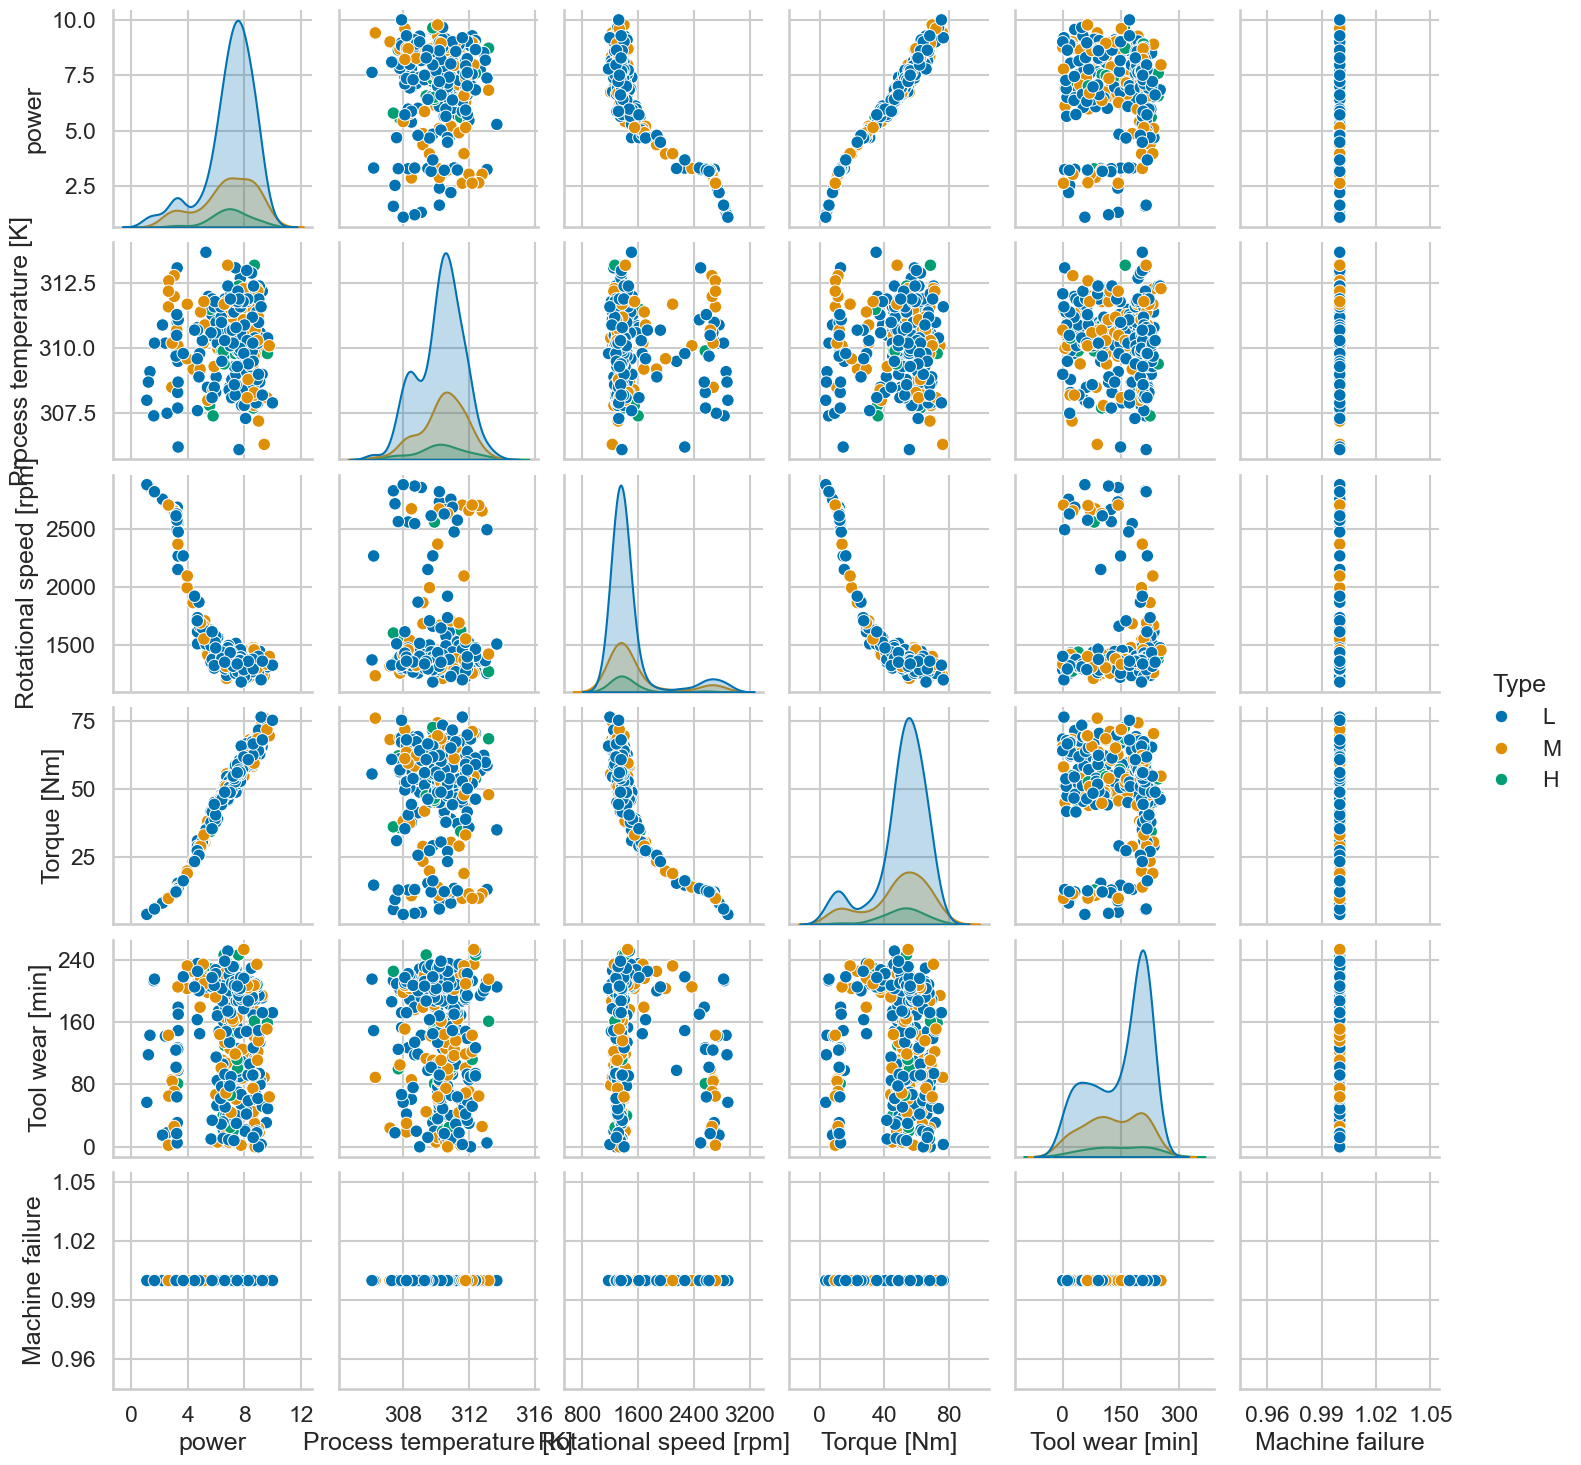

In [21]:
graf = sns.pairplot(awarie, vars=['power', 'Process temperature [K]', 'Rotational speed [rpm]','Torque [Nm]','Tool wear [min]','Machine failure',],hue='Type')
for ax in graf.axes.flatten():
    # Zwiększa liczbę wartości pokazanych na osi Y (nbins=8 oznacza około 8-10 wartości na osi)
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
    
    # Możesz też od razu zwiększyć liczbę wartości na osi X, jeśli chcesz
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
plt.show()

to może na przykładzie. Maszyna psuje się najczęściej przy obrotach w przedziale 1400-1600, pozniej ma okno bezawaryjne i awarie znowuu zaczynaja sie przy obrotach 2400.

Moment obrotowy jest jest bezpieczny miedzy 20 a 40, przy czym powyżej 40 jest już strefa duzego ryzyka niezależnie od zuzycia. niski moment tez jest niebezpieczny, jednak dużo mniej i też nie zależy od zuzycia. a najbardziej awaryjne połączenie to wysoki moment razem z niską rotacją.

optymalna rotacja jest w zakresie od 1500 do 2500 awarie poza tym zakresem nie są powiązane z zużyciem aż do 150min, po tym czasie dowolna rotacja moze powodowac awarie 

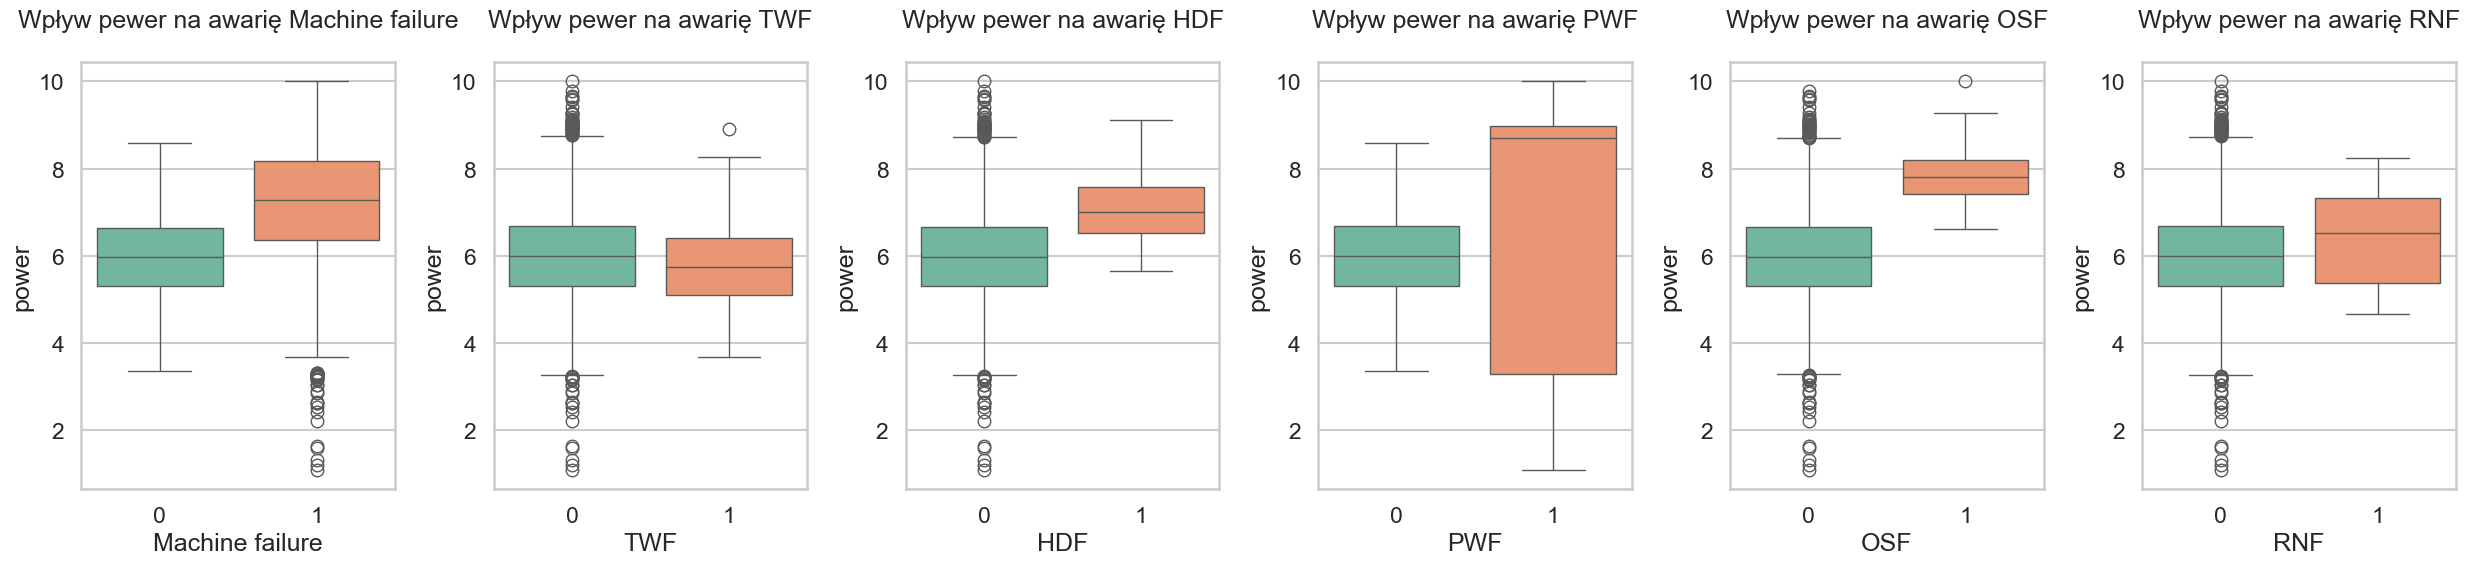

In [26]:
features = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
# Zmień 5 na 6, aby pasowało do liczby elementów w "features"
fig, axes = plt.subplots(1, 6, figsize=(25, 6)) 
for i, col in enumerate(features):
    sns.boxplot(data=df, x=col, y='power', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Wpływ pewer na awarię {col}\n')
plt.tight_layout()
plt.show()

wykresy po kolei

1) Przy braku awarii widzimy rozkład symetryczny zbliżony do normalnego, przy awariach widzimy mediane temperatur podniesioną o około 1.8 stopnia przy rozkładzie prawoskośnym dodatnim. Może to oznaczać związek pośredni między awarią o temperaturą otoczenia. 

2) przy temperaturze procesu możemy zauważyć bardzo symetryczne zbliżone ro normalnych rozkłady. Oznacza to że temperatura procesu nie ma bezpośredniego związku z liczbą awarii.

3) Tutaj widzimy mocną zależność ponad 75% awarii występuje w przypadku rotacji mniejszej niż około 1400, istnieje również duże skupisko wartości odstających przy nardzo dużych obtorach większych od 2500.

4) kolejny mocny związek , znowu 75% wszystkich awarii występuje przy torque powyżej 45 Nm występuje duże skupisko odstających wartości w okolicach 10-13 Nm

5) na tym wykresie widac oczywista zależność miedzy zuzyciem a uszkodzeniami. bezpieczna mediana czasu zuzycia wynosi niewiele ponad 100, natomiast przy 150 rysyko awari znacznie się zwiększa

ValueError: Could not interpret value `power` for `y`. An entry with this name does not appear in `data`.

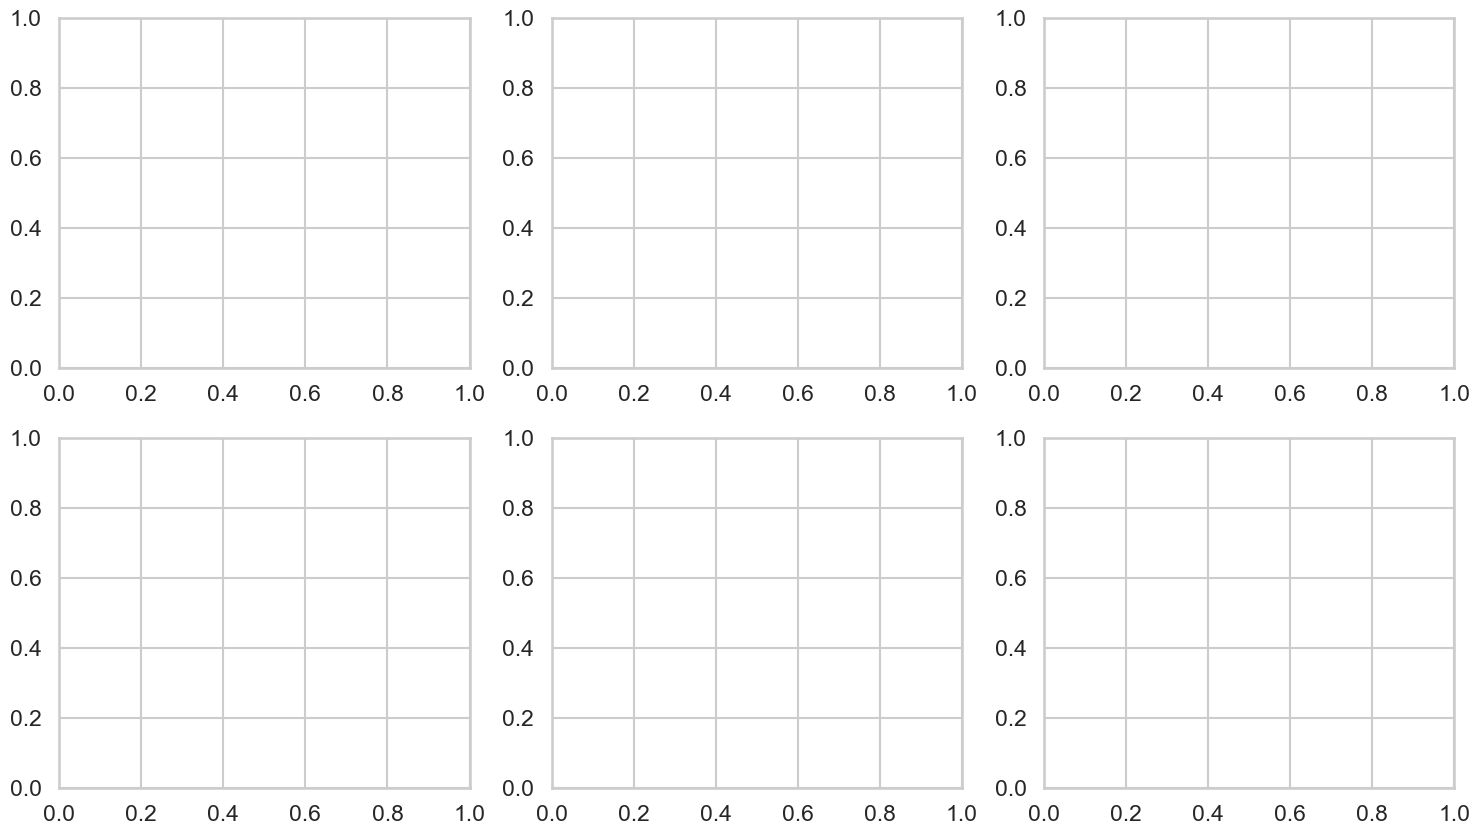

In [ ]:
features = ['Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']
# 2 wiersze, 3 kolumny
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten() # Spłaszczamy tablicę, aby iść po indeksach 0-5
for i, col in enumerate(features):
    sns.boxplot(data=df, x=col, y='power', ax=axes[i], palette='Set2')
    axes[i].set_title(f'Wpływ {col}\nna awarię')
plt.tight_layout()
plt.show()